<a href="https://colab.research.google.com/github/nasse12345r/DDos-ML/blob/main/IDS_DDos_Cload.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

dataset_path = '/content/drive/MyDrive/Colab Notebooks/FYP/DDoS2019-Dataset'

for folder in os.listdir(dataset_path):
    print(folder)

01-12
03-11
CSV-03-11.zip
CSV-01-12.zip
ddos_scaler.pkl
rf_model.pkl
xgb_model.pkl
iso_forest_model.pkl


In [ ]:
folder_path = dataset_path + '/01-12'

for file in os.listdir(folder_path):
    print(file)

TFTP.csv
DrDoS_MSSQL.csv
DrDoS_UDP.csv
DrDoS_SNMP.csv
DrDoS_SSDP.csv
DrDoS_DNS.csv
DrDoS_NTP.csv
DrDoS_NetBIOS.csv
Syn.csv
UDPLag.csv
DrDoS_LDAP.csv


In [ ]:
import pandas as pd
import os

# Update this path if your folder structure is slightly different
dataset_path = '/content/drive/MyDrive/Colab Notebooks/FYP/DDoS2019-Dataset/01-12'

# Get all CSV files in the directory
csv_files = [f for f in os.listdir(dataset_path) if f.endswith('.csv')]

sample_dfs = []
rows_per_file = 50000  # 50k rows per file is usually safe for Colab RAM

print("Loading samples from files...")
for file in csv_files:
    file_path = os.path.join(dataset_path, file)
    try:
        # Load a chunk of each file
        df_temp = pd.read_csv(file_path, nrows=rows_per_file, low_memory=False)
        sample_dfs.append(df_temp)
        print(f"Loaded {len(df_temp)} rows from {file}")
    except Exception as e:
        print(f"Skipped {file} due to error: {e}")

# Combine everything into one main DataFrame
df = pd.concat(sample_dfs, ignore_index=True)

# Pro-Tip: CIC datasets notoriously have annoying leading/trailing spaces in their column names.
# This strips them out to prevent KeyError headaches later.
df.columns = df.columns.str.strip()

print(f"\n--- Data Load Complete ---")
print(f"Total Dataset Shape: {df.shape}")
print("\nTraffic Distribution (Normal vs Attacks):")
print(df['Label'].value_counts())

Loading samples from files...
Loaded 50000 rows from TFTP.csv
Loaded 50000 rows from DrDoS_MSSQL.csv
Loaded 50000 rows from DrDoS_UDP.csv
Loaded 50000 rows from DrDoS_SNMP.csv
Loaded 50000 rows from DrDoS_SSDP.csv
Loaded 50000 rows from DrDoS_DNS.csv
Loaded 50000 rows from DrDoS_NTP.csv
Loaded 50000 rows from DrDoS_NetBIOS.csv
Loaded 50000 rows from Syn.csv
Loaded 50000 rows from UDPLag.csv
Loaded 50000 rows from DrDoS_LDAP.csv

--- Data Load Complete ---
Total Dataset Shape: (550000, 88)

Traffic Distribution (Normal vs Attacks):
Label
TFTP             49995
Syn              49995
DrDoS_LDAP       49993
DrDoS_UDP        49990
DrDoS_SNMP       49957
DrDoS_SSDP       49891
DrDoS_NetBIOS    49839
DrDoS_MSSQL      49352
DrDoS_DNS        48298
UDP-lag          48247
DrDoS_NTP        37653
BENIGN           16648
WebDDoS            142
Name: count, dtype: int64


In [ ]:
print("Dataset Shape:", df.shape)
print("\nData Types:")
print(df.dtypes.value_counts())
print("\nMissing Values:")
print(df.isnull().sum()[df.isnull().sum() > 0])

Dataset Shape: (550000, 88)

Data Types:
float64    45
int64      37
object      6
Name: count, dtype: int64

Missing Values:
Flow Bytes/s    9490
dtype: int64


In [ ]:
import numpy as np

numeric_df = df.select_dtypes(include=[np.number])
inf_counts = np.isinf(numeric_df).sum()
print("Columns with Infinite Values:")
print(inf_counts[inf_counts > 0])

Columns with Infinite Values:
Flow Bytes/s       8769
Flow Packets/s    18259
dtype: int64


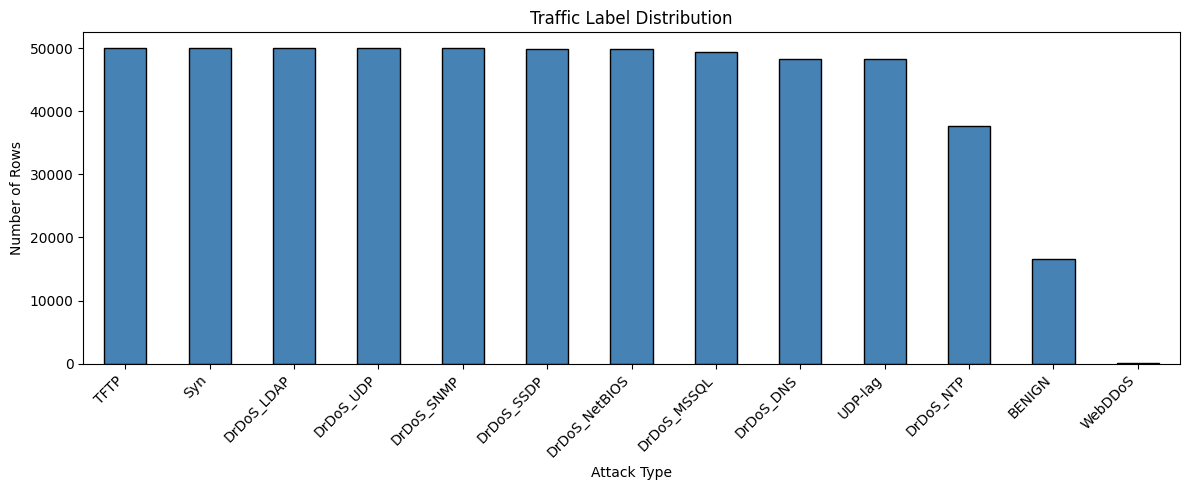

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
df['Label'].value_counts().plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Traffic Label Distribution')
plt.xlabel('Attack Type')
plt.ylabel('Number of Rows')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [ ]:
object_cols = df.select_dtypes(include='object').columns.tolist()
print("Object columns:", object_cols)

for col in object_cols:
    print(f"\n{col} unique values:")
    print(df[col].unique())

Object columns: ['Flow ID', 'Source IP', 'Destination IP', 'Timestamp', 'SimillarHTTP', 'Label']

Flow ID unique values:
['172.16.0.5-192.168.50.1-64670-64670-6'
 '172.16.0.5-192.168.50.1-16405-16405-6'
 '172.16.0.5-192.168.50.1-45838-45838-6' ...
 '172.16.0.5-192.168.50.1-933-34923-17'
 '172.16.0.5-192.168.50.1-900-52988-17'
 '172.16.0.5-192.168.50.1-934-59892-17']

Source IP unique values:
['172.16.0.5' '192.168.50.1' '192.168.50.7' '23.32.166.121'
 '192.168.50.253' '0.0.0.0' '192.168.50.6' '104.88.60.48' '104.88.29.90'
 '192.168.50.254' '8.6.0.1' '74.208.236.171' '204.154.111.115'
 '204.154.111.117' '209.85.201.108' '54.192.49.33' '204.154.111.131'
 '172.217.11.34' '23.194.108.16' '23.194.142.213' '104.88.17.251'
 '192.168.50.8' '23.194.142.15' '172.217.7.3' '172.217.11.38'
 '172.217.10.66' '172.217.6.194' '216.58.219.196' '172.217.12.129'
 '172.217.12.194' '18.235.81.250' '52.200.108.113' '52.35.236.192'
 '65.55.242.254' '38.69.238.19' '162.248.19.151' '172.217.7.1'
 '172.217.12.16

In [ ]:
# Drop identifier columns
cols_to_drop = ['Flow ID', 'Source IP', 'Source Port',
                'Destination IP', 'Destination Port', 'Timestamp']

df.drop(columns=[c for c in cols_to_drop if c in df.columns], inplace=True)
print("Dropped identifier columns")

# Replace infinite values with NaN then drop
df.replace([np.inf, -np.inf], np.nan, inplace=True)

# Drop rows with NaN
df.dropna(inplace=True)

print(f"Shape after cleaning: {df.shape}")
print(f"Remaining missing values: {df.isnull().sum().sum()}")
print(f"Remaining infinite values: {np.isinf(df.select_dtypes(include=np.number)).sum().sum()}")

Dropped identifier columns
Shape after cleaning: (531741, 82)
Remaining missing values: 0
Remaining infinite values: 0


In [ ]:
# Binary encoding: BENIGN = 0, everything else = 1
df['Label'] = df['Label'].apply(lambda x: 0 if x == 'BENIGN' else 1)

print("Label encoding done")
print(df['Label'].value_counts())

Label encoding done
Label
1    515189
0     16552
Name: count, dtype: int64


In [ ]:
# Separate benign and attack
benign = df[df['Label'] == 0]
attack = df[df['Label'] == 1]

print(f"Benign rows: {len(benign)}")
print(f"Attack rows: {len(attack)}")

# Undersample attack rows to balance classes
attack_sampled = attack.sample(n=len(benign), random_state=42)
df_balanced = pd.concat([benign, attack_sampled], ignore_index=True)

print(f"\nBalanced dataset shape: {df_balanced.shape}")
print(df_balanced['Label'].value_counts())

Benign rows: 16552
Attack rows: 515189

Balanced dataset shape: (33104, 82)
Label
0    16552
1    16552
Name: count, dtype: int64


In [ ]:
# Drop SimillarHTTP (text column, not useful for ML)
if 'SimillarHTTP' in df_balanced.columns:
    df_balanced.drop(columns=['SimillarHTTP'], inplace=True)

print(f"Shape after dropping SimillarHTTP: {df_balanced.shape}")
print(f"Remaining columns: {df_balanced.shape[1]}")

Shape after dropping SimillarHTTP: (33104, 81)
Remaining columns: 81


In [ ]:
X = df_balanced.drop('Label', axis=1)
y = df_balanced['Label']

print(f"Features shape: {X.shape}")
print(f"Labels shape: {y.shape}")
print(f"\nFeature columns:\n{X.columns.tolist()}")

Features shape: (33104, 80)
Labels shape: (33104,)

Feature columns:
['Unnamed: 0', 'Protocol', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length', 'Max Packet Length', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PSH Flag Co

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set: {X_train.shape}")
print(f"Testing set:  {X_test.shape}")
print(f"\nTraining labels:\n{y_train.value_counts()}")
print(f"\nTesting labels:\n{y_test.value_counts()}")

Training set: (26483, 80)
Testing set:  (6621, 80)

Training labels:
Label
1    13242
0    13241
Name: count, dtype: int64

Testing labels:
Label
0    3311
1    3310
Name: count, dtype: int64


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling done")
print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"X_test_scaled shape:  {X_test_scaled.shape}")

Feature scaling done
X_train_scaled shape: (26483, 80)
X_test_scaled shape:  (6621, 80)


In [ ]:
# Drop the index column
X = df_balanced.drop(['Label', 'Unnamed: 0'], axis=1)
y = df_balanced['Label']

# Redo split and scaling
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Features shape: {X.shape}")
print(f"Training set: {X_train_scaled.shape}")
print(f"Testing set: {X_test_scaled.shape}")

Features shape: (33104, 79)
Training set: (26483, 79)
Testing set: (6621, 79)


Training Random Forest...

Random Forest Results:
              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00      3311
        DDoS       1.00      1.00      1.00      3310

    accuracy                           1.00      6621
   macro avg       1.00      1.00      1.00      6621
weighted avg       1.00      1.00      1.00      6621



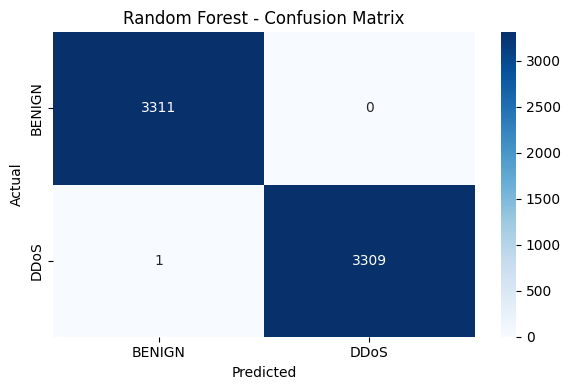

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print("Training Random Forest...")
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_scaled, y_train)

rf_preds = rf.predict(X_test_scaled)

print("\nRandom Forest Results:")
print(classification_report(y_test, rf_preds, target_names=['BENIGN', 'DDoS']))

# Confusion Matrix
cm_rf = confusion_matrix(y_test, rf_preds)
plt.figure(figsize=(6,4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=['BENIGN','DDoS'],
            yticklabels=['BENIGN','DDoS'])
plt.title('Random Forest - Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

Training XGBoost...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [15:26:34] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



XGBoost Results:
              precision    recall  f1-score   support

      BENIGN       1.00      1.00      1.00      3311
        DDoS       1.00      1.00      1.00      3310

    accuracy                           1.00      6621
   macro avg       1.00      1.00      1.00      6621
weighted avg       1.00      1.00      1.00      6621



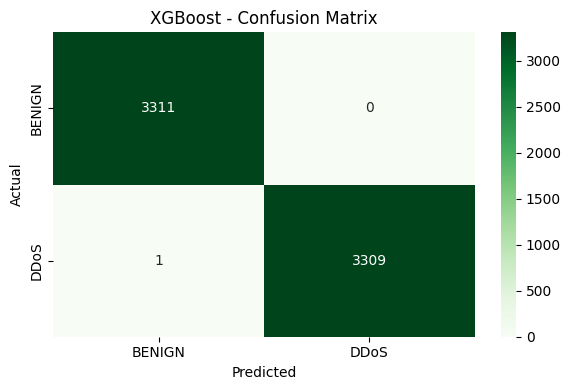

In [ ]:
from xgboost import XGBClassifier

print("Training XGBoost...")
xgb = XGBClassifier(n_estimators=100, random_state=42,
                     use_label_encoder=False,
                     eval_metric='logloss',
                     n_jobs=-1)
xgb.fit(X_train_scaled, y_train)

xgb_preds = xgb.predict(X_test_scaled)

print("\nXGBoost Results:")
print(classification_report(y_test, xgb_preds, target_names=['BENIGN', 'DDoS']))

# Confusion Matrix
cm_xgb = confusion_matrix(y_test, xgb_preds)
plt.figure(figsize=(6,4))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Greens',
            xticklabels=['BENIGN','DDoS'],
            yticklabels=['BENIGN','DDoS'])
plt.title('XGBoost - Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

Training Isolation Forest...

Isolation Forest Results:
              precision    recall  f1-score   support

      BENIGN       0.71      0.89      0.79      3311
        DDoS       0.86      0.64      0.73      3310

    accuracy                           0.77      6621
   macro avg       0.79      0.77      0.76      6621
weighted avg       0.79      0.77      0.76      6621



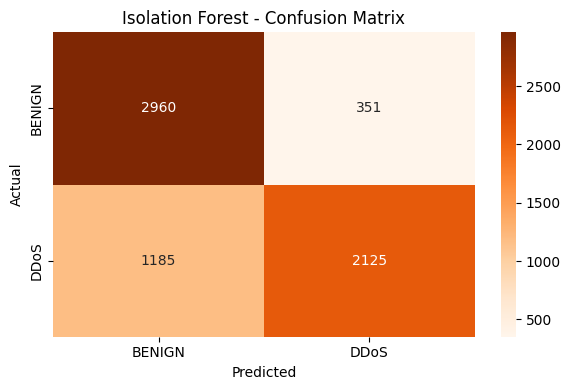

In [ ]:
from sklearn.ensemble import IsolationForest

print("Training Isolation Forest...")

# Train ONLY on benign traffic
X_train_benign = X_train_scaled[y_train == 0]

iso = IsolationForest(contamination=0.1, random_state=42, n_jobs=-1)
iso.fit(X_train_benign)

# Predict on test set (-1 = anomaly = DDoS, 1 = normal = BENIGN)
iso_raw = iso.predict(X_test_scaled)
iso_preds = [1 if x == -1 else 0 for x in iso_raw]

print("\nIsolation Forest Results:")
print(classification_report(y_test, iso_preds, target_names=['BENIGN', 'DDoS']))

# Confusion Matrix
cm_iso = confusion_matrix(y_test, iso_preds)
plt.figure(figsize=(6,4))
sns.heatmap(cm_iso, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['BENIGN','DDoS'],
            yticklabels=['BENIGN','DDoS'])
plt.title('Isolation Forest - Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

models = ['Random Forest', 'XGBoost', 'Isolation Forest']
predictions = [rf_preds, xgb_preds, iso_preds]

results = []
for name, preds in zip(models, predictions):
    results.append({
        'Model': name,
        'Accuracy':  round(accuracy_score(y_test, preds), 4),
        'Precision': round(precision_score(y_test, preds), 4),
        'Recall':    round(recall_score(y_test, preds), 4),
        'F1-Score':  round(f1_score(y_test, preds), 4)
    })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

           Model  Accuracy  Precision  Recall  F1-Score
   Random Forest    0.9998     1.0000  0.9997    0.9998
         XGBoost    0.9998     1.0000  0.9997    0.9998
Isolation Forest    0.7680     0.8582  0.6420    0.7345


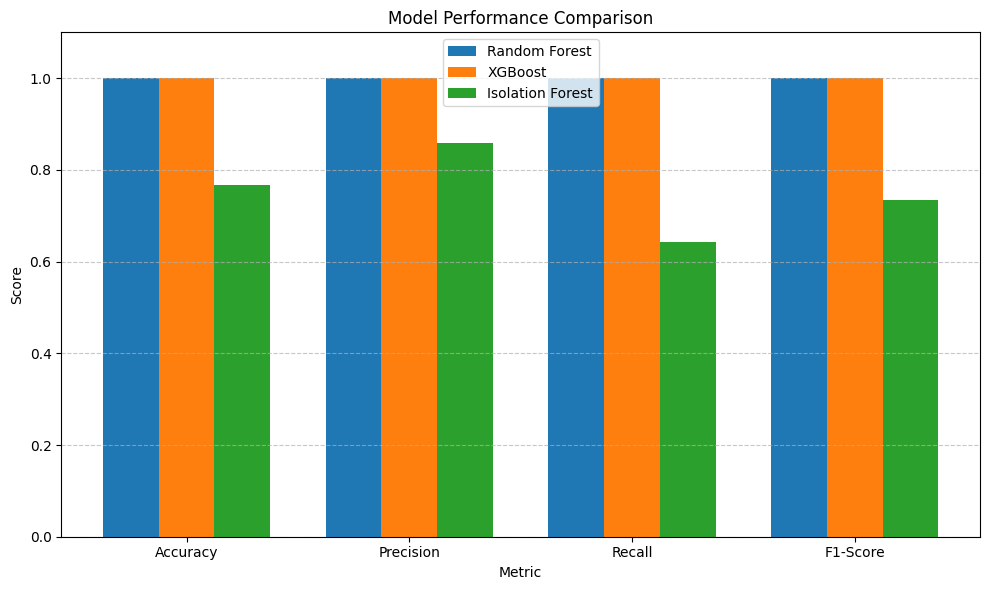

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(metrics))
width = 0.25

fig, ax = plt.subplots(figsize=(10, 6))

for i, (_, row) in enumerate(results_df.iterrows()):
    ax.bar(x + i*width, [row['Accuracy'], row['Precision'],
                          row['Recall'], row['F1-Score']],
           width, label=row['Model'])

ax.set_xlabel('Metric')
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison')
ax.set_xticks(x + width)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.1)
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

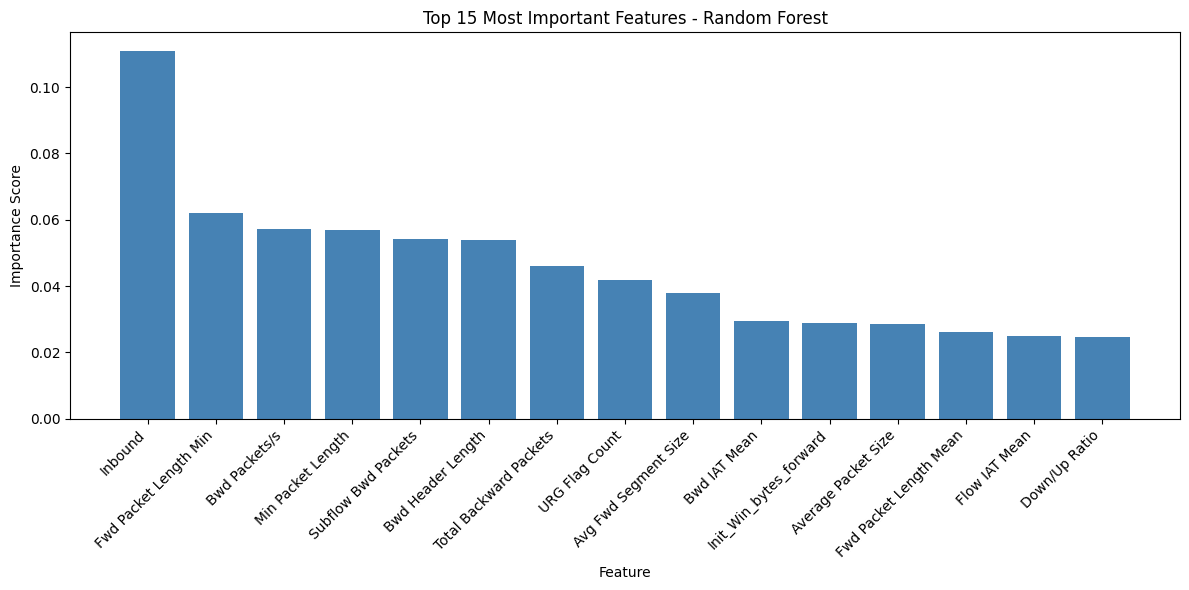

In [ ]:
feature_names = X.columns.tolist()
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1][:15]  # top 15

plt.figure(figsize=(12, 6))
plt.bar(range(15), importances[indices], color='steelblue')
plt.xticks(range(15), [feature_names[i] for i in indices],
           rotation=45, ha='right')
plt.title('Top 15 Most Important Features - Random Forest')
plt.xlabel('Feature')
plt.ylabel('Importance Score')
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import os

unseen_path = '/content/drive/MyDrive/Colab Notebooks/FYP/DDoS2019-Dataset/03-11'

# Check what files are available
for file in os.listdir(unseen_path):
    print(file)

Portmap.csv
NetBIOS.csv
LDAP.csv
MSSQL.csv
UDP.csv
UDPLag.csv
Syn.csv
.~lock.UDPLag.csv#


In [ ]:
unseen_path = '/content/drive/MyDrive/Colab Notebooks/FYP/DDoS2019-Dataset/03-11'

# Skip the lock file
valid_files = [f for f in os.listdir(unseen_path)
               if f.endswith('.csv') and not f.startswith('.')]

unseen_dfs = []
for file in valid_files:
    file_path = os.path.join(unseen_path, file)
    temp_df = pd.read_csv(file_path, nrows=3000, low_memory=False)
    temp_df.columns = temp_df.columns.str.strip()
    print(f"Loaded: {file} — Shape: {temp_df.shape}")
    unseen_dfs.append(temp_df)

df_unseen = pd.concat(unseen_dfs, ignore_index=True)
print(f"\nCombined unseen shape: {df_unseen.shape}")
print(f"\nLabel distribution:\n{df_unseen['Label'].value_counts()}")

Loaded: Portmap.csv — Shape: (3000, 88)
Loaded: NetBIOS.csv — Shape: (3000, 88)
Loaded: LDAP.csv — Shape: (3000, 88)
Loaded: MSSQL.csv — Shape: (3000, 88)
Loaded: UDP.csv — Shape: (3000, 88)
Loaded: UDPLag.csv — Shape: (3000, 88)
Loaded: Syn.csv — Shape: (3000, 88)

Combined unseen shape: (21000, 88)

Label distribution:
Label
NetBIOS    5996
UDP        3000
MSSQL      3000
Syn        3000
LDAP       2994
BENIGN     2502
Portmap     508
Name: count, dtype: int64


In [ ]:
# Drop same columns as training
cols_to_drop = ['Flow ID', 'Source IP', 'Destination IP',
                'Timestamp', 'SimillarHTTP', 'Unnamed: 0']

df_unseen.drop(columns=[c for c in cols_to_drop if c in df_unseen.columns],
               inplace=True)

# Replace infinities and drop NaN
df_unseen.replace([np.inf, -np.inf], np.nan, inplace=True)
df_unseen.dropna(inplace=True)

# Encode labels
df_unseen['Label'] = df_unseen['Label'].apply(
    lambda x: 0 if x == 'BENIGN' else 1)

print(f"Shape after cleaning: {df_unseen.shape}")
print(f"\nLabel distribution:\n{df_unseen['Label'].value_counts()}")

Shape after cleaning: (20342, 82)

Label distribution:
Label
1    17857
0     2485
Name: count, dtype: int64


In [ ]:
# Separate features and labels
X_unseen = df_unseen.drop('Label', axis=1)
y_unseen = df_unseen['Label']

# Keep only columns that exist in training data
X_unseen = X_unseen[[col for col in X.columns if col in X_unseen.columns]]

# Add any missing columns as 0
for col in X.columns:
    if col not in X_unseen.columns:
        X_unseen[col] = 0

# Reorder to match training
X_unseen = X_unseen[X.columns]

# Scale using the SAME scaler from training
X_unseen_scaled = scaler.transform(X_unseen)

print(f"Unseen features shape: {X_unseen_scaled.shape}")
print("Feature alignment done")

Unseen features shape: (20342, 79)
Feature alignment done


In [ ]:
from sklearn.metrics import classification_report, accuracy_score
from sklearn.metrics import precision_score, recall_score, f1_score

# Random Forest
rf_unseen = rf.predict(X_unseen_scaled)
# XGBoost
xgb_unseen = xgb.predict(X_unseen_scaled)
# Isolation Forest
iso_raw_unseen = iso.predict(X_unseen_scaled)
iso_unseen = [1 if x == -1 else 0 for x in iso_raw_unseen]

print("="*50)
print("UNSEEN ATTACK TEST RESULTS")
print("="*50)

models_unseen = {
    'Random Forest': rf_unseen,
    'XGBoost': xgb_unseen,
    'Isolation Forest': iso_unseen
}

unseen_results = []
for name, preds in models_unseen.items():
    print(f"\n{name}:")
    print(classification_report(y_unseen, preds,
                                target_names=['BENIGN', 'DDoS']))
    unseen_results.append({
        'Model': name,
        'Accuracy':  round(accuracy_score(y_unseen, preds), 4),
        'Precision': round(precision_score(y_unseen, preds, zero_division=0), 4),
        'Recall':    round(recall_score(y_unseen, preds, zero_division=0), 4),
        'F1-Score':  round(f1_score(y_unseen, preds, zero_division=0), 4)
    })

unseen_df = pd.DataFrame(unseen_results)
print("\nSUMMARY TABLE - UNSEEN ATTACKS:")
print(unseen_df.to_string(index=False))

UNSEEN ATTACK TEST RESULTS

Random Forest:
              precision    recall  f1-score   support

      BENIGN       0.80      1.00      0.89      2485
        DDoS       1.00      0.96      0.98     17857

    accuracy                           0.97     20342
   macro avg       0.90      0.98      0.93     20342
weighted avg       0.97      0.97      0.97     20342


XGBoost:
              precision    recall  f1-score   support

      BENIGN       0.99      1.00      0.99      2485
        DDoS       1.00      1.00      1.00     17857

    accuracy                           1.00     20342
   macro avg       1.00      1.00      1.00     20342
weighted avg       1.00      1.00      1.00     20342


Isolation Forest:
              precision    recall  f1-score   support

      BENIGN       0.18      0.89      0.30      2485
        DDoS       0.97      0.44      0.61     17857

    accuracy                           0.50     20342
   macro avg       0.57      0.67      0.45     20342
we

In [ ]:
import joblib
import os

# Create a folder to save models
save_path = '/content/drive/MyDrive/Colab Notebooks/FYP/Models'
os.makedirs(save_path, exist_ok=True)

# Save all three models and the scaler
joblib.dump(rf, os.path.join(save_path, 'random_forest.pkl'))
joblib.dump(xgb, os.path.join(save_path, 'xgboost.pkl'))
joblib.dump(iso, os.path.join(save_path, 'isolation_forest.pkl'))
joblib.dump(scaler, os.path.join(save_path, 'scaler.pkl'))

# Save feature names so Kali system knows which columns to use
feature_names = X.columns.tolist()
joblib.dump(feature_names, os.path.join(save_path, 'feature_names.pkl'))

print("All models saved successfully!")
print(f"\nSaved to: {save_path}")
print("\nFiles saved:")
for f in os.listdir(save_path):
    size = os.path.getsize(os.path.join(save_path, f))
    print(f"  {f} — {size/1024/1024:.2f} MB")

All models saved successfully!

Saved to: /content/drive/MyDrive/Colab Notebooks/FYP/Models

Files saved:
  random_forest.pkl — 1.13 MB
  xgboost.pkl — 0.12 MB
  isolation_forest.pkl — 0.74 MB
  scaler.pkl — 0.00 MB
  feature_names.pkl — 0.00 MB


In [ ]:
# Test that models load and predict correctly
rf_loaded = joblib.load(os.path.join(save_path, 'random_forest.pkl'))
xgb_loaded = joblib.load(os.path.join(save_path, 'xgboost.pkl'))
iso_loaded = joblib.load(os.path.join(save_path, 'isolation_forest.pkl'))
scaler_loaded = joblib.load(os.path.join(save_path, 'scaler.pkl'))
features_loaded = joblib.load(os.path.join(save_path, 'feature_names.pkl'))

# Quick test prediction
test_sample = X_test_scaled[:5]
print("RF test predictions:", rf_loaded.predict(test_sample))
print("XGB test predictions:", xgb_loaded.predict(test_sample))
print("ISO test predictions:", iso_loaded.predict(test_sample))
print(f"\nNumber of features: {len(features_loaded)}")
print("Models verified successfully!")

RF test predictions: [0 0 1 1 1]
XGB test predictions: [0 0 1 1 1]
ISO test predictions: [ 1  1 -1  1 -1]

Number of features: 79
Models verified successfully!


#Fix 3 — Retrain and Resave Models in Colab
Actually the cleanest fix for the version issue is to resave the models in Colab. Run this in a new Colab cell: **bold text**

In [ ]:
import sklearn
print("Sklearn version in Colab:", sklearn.__version__)

# Resave all models
import joblib
joblib.dump(rf, os.path.join(save_path, 'random_forest.pkl'), protocol=2)
joblib.dump(xgb, os.path.join(save_path, 'xgboost.pkl'), protocol=2)
joblib.dump(iso, os.path.join(save_path, 'isolation_forest.pkl'), protocol=2)
joblib.dump(scaler, os.path.join(save_path, 'scaler.pkl'), protocol=2)
joblib.dump(feature_names, os.path.join(save_path, 'feature_names.pkl'), protocol=2)
print("Models resaved with protocol=2")

Sklearn version in Colab: 1.6.1
Models resaved with protocol=2
